# Mushroom

## EDA

### EXTRA UITLEG VOOR RAPPORTERING NOG NODIG

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ms = pd.read_csv("./mushroom_project_dataset.csv")
ms.head()

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


In [7]:
ms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cap-diameter       2968 non-null   float64
 1   stem-height        3987 non-null   float64
 2   stem-width         4605 non-null   float64
 3   spore-print-color  260 non-null    object 
 4   gill-color         4011 non-null   object 
 5   habitat            3996 non-null   object 
 6   season             4027 non-null   object 
 7   ring-type          4423 non-null   object 
 8   cap-shape          4594 non-null   object 
 9   stem-surface       1641 non-null   object 
 10  jumbled_noise_0    4594 non-null   object 
 11  jumbled_noise_1    4594 non-null   object 
 12  class              5000 non-null   object 
dtypes: float64(3), object(10)
memory usage: 507.9+ KB


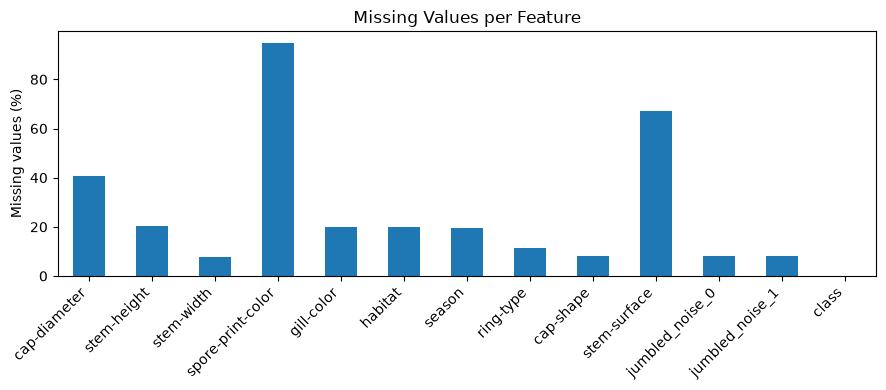

In [13]:
missing = (ms.isna().mean() * 100)

missing.plot(kind="bar", figsize=(9, 4))
plt.title("Missing Values per Feature")
plt.ylabel("Missing values (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

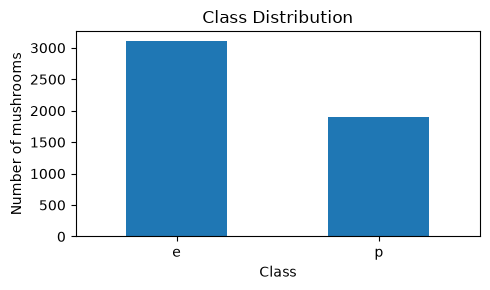

In [16]:
ms["class"].value_counts().plot(kind="bar", figsize=(5, 3))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of mushrooms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
print("Unique values per column:")
print(ms.nunique())

Unique values per column:
cap-diameter         1238
stem-height          1086
stem-width           2221
spore-print-color       7
gill-color             12
habitat                 8
season                  4
ring-type               8
cap-shape               7
stem-surface            8
jumbled_noise_0         7
jumbled_noise_1         7
class                   2
dtype: int64


In [23]:
zero_measurements = ms[
    (ms["stem-height"] == 0) |
    (ms["stem-width"] == 0)
]

print("Rows with zero measurements:", len(zero_measurements))

display(zero_measurements.head(10))

Rows with zero measurements: 60


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
46,4.30,0.0,NaN,n,w,d,a,f,o,f,p,x,e
137,4.29,0.0,0.0,n,w,NaN,u,f,o,f,b,f,p
163,4.84,0.0,0.0,n,w,d,u,f,o,f,x,c,p
232,NaN,0.0,0.0,NaN,f,d,w,f,o,f,f,NaN,p
273,4.91,NaN,0.0,n,w,d,NaN,f,o,f,x,f,p
435,3.59,0.0,0.0,NaN,f,d,NaN,f,o,f,b,f,p
472,4.04,0.0,0.0,NaN,f,d,s,f,o,f,x,p,p
523,4.75,0.0,0.0,NaN,f,d,NaN,f,o,f,x,o,p
580,NaN,0.0,0.0,NaN,NaN,d,a,f,o,f,f,x,p
621,4.91,0.0,0.0,n,w,d,NaN,f,o,f,s,f,p


In [28]:
ms_clean = ms.copy()

ms_clean[["stem-height", "stem-width"]] = (
    ms_clean[["stem-height", "stem-width"]].replace(0, np.nan)
)

print("\nMissing values:")
print(ms_clean.isna().sum().sort_values(ascending=False).head(10))

print("\nRemaining zero measurements:")
print((ms_clean[["stem-height", "stem-width"]] == 0).sum())


Missing values:
spore-print-color    4740
stem-surface         3359
cap-diameter         2032
stem-height          1062
habitat              1004
gill-color            989
season                973
ring-type             577
stem-width            452
cap-shape             406
dtype: int64

Remaining zero measurements:
stem-height    0
stem-width     0
dtype: int64


In [41]:
ms_clean.head()

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


Height en width hadden meerdere instanties van 0 als vaLue. Deze zijn opgeschoond naar None. 

## Prediction

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [32]:
data = ms_clean

X = data.drop(columns="class")
y = data["class"]

numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 0.787

Classification report:
              precision    recall  f1-score   support

           e       0.81      0.85      0.83       621
           p       0.74      0.68      0.71       379

    accuracy                           0.79      1000
   macro avg       0.78      0.77      0.77      1000
weighted avg       0.78      0.79      0.79      1000



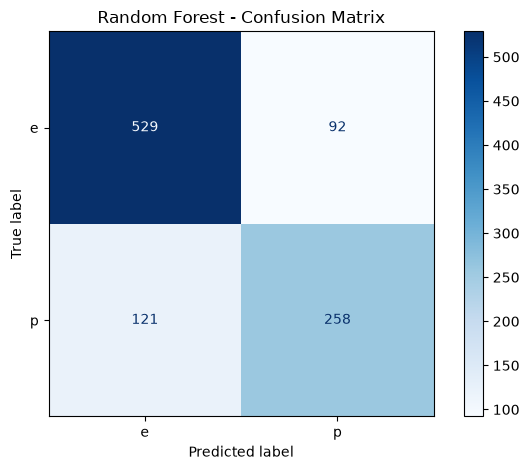

In [38]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [42]:
#TRUE RESULT = POISONOUS

new_mushroom = pd.DataFrame([{
    "cap-diameter": 10.4,
    "stem-height": 9.55,
    "stem-width": 19.64,
    "spore-print-color": None,
    "gill-color": None,
    "habitat": "d",
    "season": "a",
    "ring-type": "f",
    "cap-shape": "x",
    "stem-surface": None,
    "jumbled_noise_0": "x",
    "jumbled_noise_1": "o"
}])

prediction = model.predict(new_mushroom)

print("Predicted class:", prediction[0])

Predicted class: e


In [43]:
#TRUE RESULT = POISONOUS

new_mushroom = pd.DataFrame([{
    "cap-diameter": 0.75,
    "stem-height": 3.49,
    "stem-width": 0.71,
    "spore-print-color": None,
    "gill-color": "y",
    "habitat": "d",
    "season": "a",
    "ring-type": "f",
    "cap-shape": "x",
    "stem-surface": None,
    "jumbled_noise_0": "x",
    "jumbled_noise_1": "s"
}])

prediction = model.predict(new_mushroom)

print("Predicted class:", prediction[0])

Predicted class: p


Het model heeft een accuraatheid van 78%. Het heeft een voorkeur voor edible als resultaat, wat waarschijnlijk een bias is door de grotere hoeveelheid E-types in de trainingset.